# Notebook for Politifact fact-check Classification

## Victoria Knapp Perez, Jason LaRuez
Original data source:
- Politifact: https://www.kaggle.com/datasets/rmisra/politifact-fact-check-dataset/data

In this notebook we train a logistic regression and a LSTM model for classifying statements using the Politifact fact-check dataset. We approach three problems:
1. A 6-class classification where each class is the politifact verdict, taking values "pants-fire", "false", "mostly-false", "half-true", "mostly-true" and "true".
2. A 3-class classification where we group pants-fire and false as "False", mostly-false and half-true as "Mixed", and mostly-true and true as "True".
3. A 2-class classification where we group pants-fire, false and mostly-false as "False", and half-true, mostly-true and true as "True".
---

## Importing necessary packages

In [1]:
# Importing data
import kagglehub
import os
import json

import matplotlib.pyplot as plt # Plotting
import pandas as pd # Pandas dataframes
import numpy as np # Numpy arrays

from collections import Counter # For counting word occurrences
import string # string processing and tokenization

from sklearn.model_selection import train_test_split
from sklearn.metrics import recall_score, precision_score, roc_auc_score
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, classification_report, confusion_matrix #Analytics tools
from imblearn.over_sampling import RandomOverSampler

! pip install -Uqq fastbook

import fastbook
from fastbook import *
from fastai.text.all import *
from fastai.collab import *
from fastai.tabular.all import *
import torch
from fastai.callback.rnn import RNNRegularizer #Regulariza RNN
import time

def clean_and_tokenize(text):
    """Removes punctuation, converts to lowercase, and tokenizes text."""
    if isinstance(text, str):
        text = text.translate(str.maketrans('', '', string.punctuation))
        text = text.lower()
        return text.split()
    return [] # Return empty list for non-string inputs

# list of "stop words" from NLTK: These are words which are considered not to have much value in NLP
stop_words = ["i", "me", "my", "myself", "we", "our", "ours", "ourselves", "you", "your", "yours", "yourself",
              "yourselves", "he", "him", "his", "himself", "she", "her", "hers", "herself", "it", "its", "itself",
              "they", "them", "their", "theirs", "themselves", "what", "which", "who", "whom", "this", "that",
              "these", "those", "am", "is", "are", "was", "were", "be", "been", "being", "have", "has", "had",
              "having", "do", "does", "did", "doing", "a", "an", "the", "and", "but", "if", "or", "because",
              "as", "until", "while", "of", "at", "by", "for", "with", "about", "against", "between", "into",
              "through", "during", "before", "after", "above", "below", "to", "from", "up", "down", "in", "out",
              "on", "off", "over", "under", "again", "further", "then", "once", "here", "there", "when", "where",
              "why", "how", "all", "any", "both", "each", "few", "more", "most", "other", "some", "such", "no",
              "nor", "not", "only", "own", "same", "so", "than", "too", "very", "s", "t", "can", "will", "just",
              "don", "should", "now"]

---
## Loading in Politifact Data

In [2]:
# Download latest version of data
path = kagglehub.dataset_download("rmisra/politifact-fact-check-dataset")

print("Path to dataset files:", path)

# List all files in the downloaded dataset directory
files = os.listdir(path)

# Load the data
json_files = [f for f in files if f.endswith('.json')]

# Load the first JSON file found
data_file = os.path.join(path, json_files[0])

# Read the JSON file
# This joins the multiple json files into a single dataframe
df = pd.read_json(data_file, lines=True)

Using Colab cache for faster access to the 'politifact-fact-check-dataset' dataset.
Path to dataset files: /kaggle/input/politifact-fact-check-dataset


---
## Constructing Train-Validation-Test Sets
First we create verdict mappings for each classification problem. Next, we create an 80-10-10 Train-validation-test split for each problem. In order to handle class imbalances, we then oversample each training set until each class has the same number of occurrences as the majority class. Finally we combine the oversampled training sets with the validation sets to feed into the dataloaders for model training.

In [3]:
# Define the mapping functions for 6, 3 and 2-class classification problems

def map_6_verdict(verdict):
    if verdict == 'pants-fire':
        return 0
    elif verdict == 'false':
        return 1
    elif verdict == 'mostly-false':
        return 2
    elif verdict == 'half-true':
        return 3
    elif verdict == 'mostly-true':
        return 4
    elif verdict == 'true':
        return 5
    else:
        return verdict

def map_3_verdict(verdict):
    if verdict in ['pants-fire', 'false',0,1]:
        return 0
    elif verdict in ['mostly-false', 'half-true',2,3]:
        return 1
    elif verdict in ['mostly-true', 'true',4,5]:
        return 2
    else:
        return None

def map_2_verdict(verdict):
    if verdict in ['pants-fire', 'false', 'mostly-false',0,1,2]:
        return 0
    elif verdict in ['half-true','mostly-true', 'true',3,4,5]:
        return 1
    else:
        return None

# Create the new verdict columns
df['three_class_verdict'] = df['verdict'].apply(map_3_verdict)
df['two_class_verdict'] = df['verdict'].apply(map_2_verdict)
df['verdict'] = df['verdict'].apply(map_6_verdict)

# Set a random seed for reproducibility
np.random.seed(42)

# Construct an 80-20 train-test split
X = df['statement'].values
y_six_class = df['verdict'].values
y_three_class = df['three_class_verdict'].values
y_two_class = df['two_class_verdict'].values

# We split 80-20 training test split, then split the 20% training set in half to create a
# 10% validation set and 10% test set.
X_train_six_class, X_test_six_class, y_train_six_class, y_test_six_class = train_test_split(
    X, y_six_class, test_size=0.2, random_state=42, stratify=y_six_class)

X_val_six_class, X_test_six_class, y_val_six_class, y_test_six_class = train_test_split(
    X_test_six_class, y_test_six_class, test_size=0.5, random_state=42, stratify=y_test_six_class)

X_train_three_class, X_test_three_class, y_train_three_class, y_test_three_class = train_test_split(
    X, y_three_class, test_size=0.2, random_state=42, stratify=y_three_class)

X_val_three_class, X_test_three_class, y_val_three_class, y_test_three_class = train_test_split(
    X_test_three_class, y_test_three_class, test_size=0.2, random_state=42, stratify=y_test_three_class)

X_train_two_class, X_test_two_class, y_train_two_class, y_test_two_class = train_test_split(
    X, y_two_class, test_size=0.2, random_state=42, stratify=y_two_class)

X_val_two_class, X_test_two_class, y_val_two_class, y_test_two_class = train_test_split(
    X_test_two_class, y_test_two_class, test_size=0.5, random_state=42, stratify=y_test_two_class)

# Oversample minority classes for the 6-class problem
ros_six = RandomOverSampler(random_state=42)
X_train_six_class_resampled, y_train_six_class_resampled = ros_six.fit_resample(X_train_six_class.reshape(-1, 1), y_train_six_class)
X_train_six_class_resampled = X_train_six_class_resampled.flatten()

# Oversample minority classes for the 3-class problem
ros_three = RandomOverSampler(random_state=42)
X_train_three_class_resampled, y_train_three_class_resampled = ros_three.fit_resample(X_train_three_class.reshape(-1, 1), y_train_three_class)
X_train_three_class_resampled = X_train_three_class_resampled.flatten()

# Oversample minority classes for the 2-class problem
ros_two = RandomOverSampler(random_state=42)
X_train_two_class_resampled, y_train_two_class_resampled = ros_two.fit_resample(X_train_two_class.reshape(-1, 1), y_train_two_class)
X_train_two_class_resampled = X_train_two_class_resampled.flatten()

# Combine oversampled training sets with validation set for dataloader
X_train_val_six_class = pd.concat([pd.DataFrame(X_train_six_class_resampled), pd.DataFrame(X_val_six_class)])[0].values
y_train_val_six_class = pd.concat([pd.DataFrame(y_train_six_class_resampled), pd.DataFrame(y_val_six_class)])[0].values

X_train_val_three_class = pd.concat([pd.DataFrame(X_train_three_class_resampled), pd.DataFrame(X_val_three_class)])[0].values
y_train_val_three_class = pd.concat([pd.DataFrame(y_train_three_class_resampled), pd.DataFrame(y_val_three_class)])[0].values

X_train_val_two_class = pd.concat([pd.DataFrame(X_train_two_class_resampled), pd.DataFrame(X_val_two_class)])[0].values
y_train_val_two_class = pd.concat([pd.DataFrame(y_train_two_class_resampled), pd.DataFrame(y_val_two_class)])[0].values

# Get training vs validation indices to tell data loaders where validation set it
train_indices_six_class = pd.DataFrame(X_train_six_class_resampled).index.tolist()
val_indices_six_class = [i + len(X_train_six_class_resampled) for i in pd.DataFrame(X_val_six_class).index.tolist()] # Adjust indices for the combined df
custom_cv_six_class = [(train_indices_six_class, val_indices_six_class)]

train_indices_three_class = pd.DataFrame(X_train_three_class_resampled).index.tolist()
val_indices_three_class = [i + len(X_train_three_class_resampled) for i in pd.DataFrame(X_val_three_class).index.tolist()] # Adjust indices for the combined df
custom_cv_three_class = [(train_indices_three_class, val_indices_three_class)]

train_indices_two_class = pd.DataFrame(X_train_two_class_resampled).index.tolist()
val_indices_two_class = [i + len(X_train_two_class_resampled) for i in pd.DataFrame(X_val_two_class).index.tolist()] # Adjust indices for the combined df
custom_cv_two_class = [(train_indices_two_class, val_indices_two_class)]

---
# Baseline Model: Multi-Class Logistic Regression
As a baseline model to compare to, we train a multi-class logistic regression model which, rather than outputting binary probabilities, outputs a probability for each class. According to "A benchmark study of machine learning models for online fake news detection", sentiment features are NOT useful for fake news detection, so instead we will rely on linguistic features:
1. Term-frequency $tf(t,d)$, the number of times term $t$ occurs in document $d$.
2. Inverse-document-frequency (when `scikit-learn` setting `smooth_idf` == True):
$$idf(t)=\log{\frac{1+n_d}{1+df(t)}}$$
where $n_d$ is the $n_d$ is the total number of documents in the corpus, and $df(t)$ is the document frequency of the term $t$ (the number of documents that contain the term $t$). If a word occurs in every document, then the idf of that word is 0, thus words that occur in most documents (such as stop words) are given very little weight.
3. Term frequency-inverse document frequency (the features we use in our model):
$$tf\text{-}idf(t,d) = tf(t,d)\cdot (1+idf(t))$$

In [4]:
from sklearn.model_selection import GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(strip_accents=None,
                        lowercase=False,
                        preprocessor=None)

small_param_grid = [
{
  'vect__ngram_range': [(1, 1),(1,2),(1,3)],
  'vect__stop_words': [stop_words, None],
  'vect__tokenizer': [clean_and_tokenize],
  'clf__penalty': ['l1','l2'],
  'clf__C': [1.0, 5.0, 10.0]
},
]
lr_tfidf = Pipeline([
  ('vect', tfidf),
  ('clf', LogisticRegression(solver='liblinear'))
])

start = time.time()
gs_lr_tfidf = GridSearchCV(lr_tfidf, small_param_grid,
scoring='accuracy', cv=custom_cv_six_class,
verbose=2, n_jobs=-1)
gs_lr_tfidf.fit(X_train_val_six_class, y_train_val_six_class)
end = time.time()

print(f'Best parameter set: {gs_lr_tfidf.best_params_}')

print(f'Validation Accuracy: {gs_lr_tfidf.best_score_:.3f}')

clf_six_class = gs_lr_tfidf.best_estimator_
print(f'Test Accuracy: {clf_six_class.score(X_test_six_class, y_test_six_class):.3f}')
print(f'Time to run gridsearch + final fit: {end-start:.2f} seconds')

Fitting 1 folds for each of 36 candidates, totalling 36 fits


/usr/local/lib/python3.12/dist-packages/sklearn/feature_extraction/text.py:517: UserWarning: The parameter 'token_pattern' will not be used since 'tokenizer' is not None'
  warnings.warn(


Best parameter set: {'clf__C': 10.0, 'clf__penalty': 'l2', 'vect__ngram_range': (1, 3), 'vect__stop_words': None, 'vect__tokenizer': <function clean_and_tokenize at 0x7ba1147a5bc0>}
Validation Accuracy: 0.305
Test Accuracy: 0.302
Time to run gridsearch + final fit: 110.65 seconds


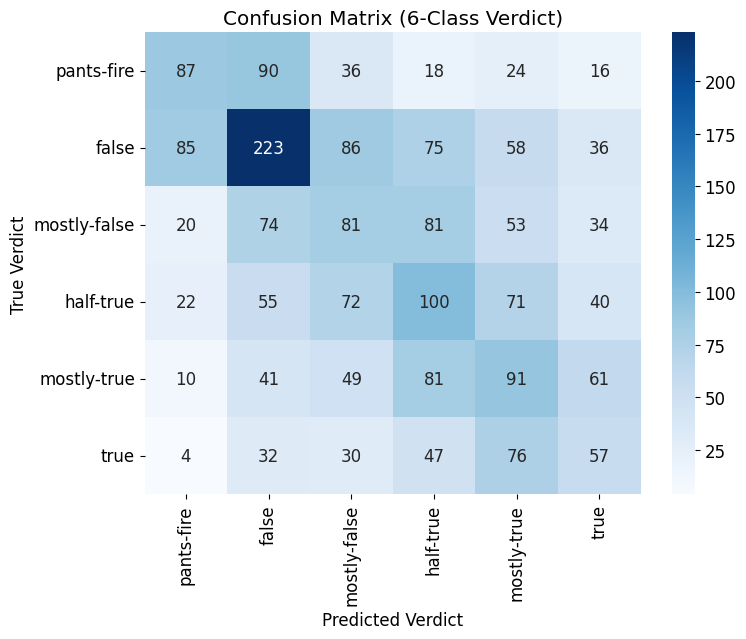


--- 6-Class Logistic Regression Model Metrics ---
Recall (Logistic Regression): 0.289
Precision (Logistic Regression): 0.295
AUC (Logistic Regression): 0.667


In [5]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

# Confusion Matrix for the 6-class problem
y_pred_six_class = clf_six_class.predict(X_test_six_class)
cm = confusion_matrix(y_test_six_class, y_pred_six_class, labels=[0,1,2,3,4,5])

verdict_order = ['pants-fire','false','mostly-false','half-true','mostly-true','true']
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=verdict_order, yticklabels=verdict_order)
plt.title('Confusion Matrix (6-Class Verdict)')
plt.xlabel('Predicted Verdict')
plt.ylabel('True Verdict')
plt.show()

# Evaluate Recall, Precision, and AUC for the 6-class Logistic Regression Model
y_true_lr = y_test_six_class.tolist()

# Get prediction probabilities for AUC
y_pred_proba_lr = clf_six_class.predict_proba(X_test_six_class)

# Calculate metrics
recall_lr = recall_score(y_true_lr, y_pred_six_class, average='macro', zero_division=0)
precision_lr = precision_score(y_true_lr, y_pred_six_class, average='macro', zero_division=0)
auc_lr = roc_auc_score(y_true_lr, y_pred_proba_lr, average='macro', multi_class='ovo')

print("\n--- 6-Class Logistic Regression Model Metrics ---")
print(f"Recall (Logistic Regression): {recall_lr:.3f}")
print(f"Precision (Logistic Regression): {precision_lr:.3f}")
print(f"AUC (Logistic Regression): {auc_lr:.3f}")

In [6]:
# Rerun the GridSearchCV with the new target variable
start = time.time()
gs_lr_tfidf_three_class = GridSearchCV(lr_tfidf, small_param_grid,
                                       scoring='accuracy', cv=custom_cv_three_class,
                                       verbose=2, n_jobs=-1)
gs_lr_tfidf_three_class.fit(X_train_val_three_class, y_train_val_three_class)
end = time.time()

print(f'Best parameter set (three-class): {gs_lr_tfidf_three_class.best_params_}')
print(f'Valdation Accuracy (three-class): {gs_lr_tfidf_three_class.best_score_:.3f}')

clf_three_class = gs_lr_tfidf_three_class.best_estimator_
print(f'Test Accuracy (three-class): {clf_three_class.score(X_test_three_class, y_test_three_class):.3f}')
print(f'Time to run gridsearch + final fit: {end-start:.2f} seconds')

Fitting 1 folds for each of 36 candidates, totalling 36 fits


/usr/local/lib/python3.12/dist-packages/sklearn/feature_extraction/text.py:517: UserWarning: The parameter 'token_pattern' will not be used since 'tokenizer' is not None'
  warnings.warn(


Best parameter set (three-class): {'clf__C': 1.0, 'clf__penalty': 'l2', 'vect__ngram_range': (1, 3), 'vect__stop_words': None, 'vect__tokenizer': <function clean_and_tokenize at 0x7ba1147a5bc0>}
Valdation Accuracy (three-class): 0.520
Test Accuracy (three-class): 0.555
Time to run gridsearch + final fit: 23.04 seconds


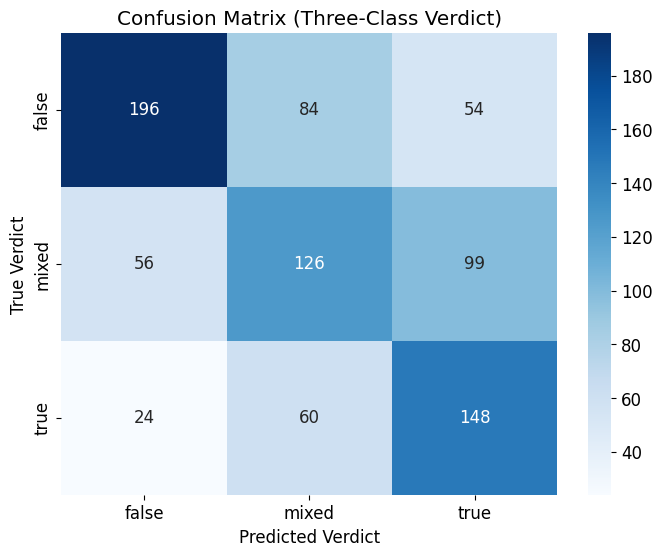


--- 3-Class Logistic Regression Model Metrics ---
Recall (Logistic Regression): 0.558
Precision (Logistic Regression): 0.556
AUC (Logistic Regression): 0.726


In [7]:
# Confusion Matrix for the 3-class problem
y_pred_three_class = clf_three_class.predict(X_test_three_class)
three_class_order = ['false', 'mixed', 'true']
cm_three_class = confusion_matrix(y_test_three_class, y_pred_three_class, labels=[0,1,2])

plt.figure(figsize=(8, 6))
sns.heatmap(cm_three_class, annot=True, fmt='d', cmap='Blues', xticklabels=three_class_order, yticklabels=three_class_order)
plt.title('Confusion Matrix (Three-Class Verdict)')
plt.xlabel('Predicted Verdict')
plt.ylabel('True Verdict')
plt.show()

# Evaluate Recall, Precision, and AUC for the 3-class Logistic Regression Model
y_true_lr = y_test_three_class.tolist()

# Get prediction probabilities for AUC
y_pred_proba_lr = clf_three_class.predict_proba(X_test_three_class)

# Calculate metrics
recall_lr = recall_score(y_true_lr, y_pred_three_class, average='macro', zero_division=0)
precision_lr = precision_score(y_true_lr, y_pred_three_class, average='macro', zero_division=0)
auc_lr = roc_auc_score(y_true_lr, y_pred_proba_lr, average='macro', multi_class='ovo')

print("\n--- 3-Class Logistic Regression Model Metrics ---")
print(f"Recall (Logistic Regression): {recall_lr:.3f}")
print(f"Precision (Logistic Regression): {precision_lr:.3f}")
print(f"AUC (Logistic Regression): {auc_lr:.3f}")

In [8]:
# Rerun the GridSearchCV with the new target variable
start = time.time()
gs_lr_tfidf_two_class = GridSearchCV(lr_tfidf, small_param_grid,
                                       scoring='accuracy', cv=custom_cv_two_class,
                                       verbose=2, n_jobs=-1)
gs_lr_tfidf_two_class.fit(X_train_val_two_class, y_train_val_two_class)
end = time.time()

print(f'Best parameter set (two-class): {gs_lr_tfidf_two_class.best_params_}')
print(f'Validation Accuracy (two-class): {gs_lr_tfidf_two_class.best_score_:.3f}')

clf_two_class = gs_lr_tfidf_two_class.best_estimator_
print(f'Test Accuracy (two-class): {clf_two_class.score(X_test_two_class, y_test_two_class):.3f}')
print(f'Time to run gridsearch + final fit: {end-start:.2f} seconds')

Fitting 1 folds for each of 36 candidates, totalling 36 fits


/usr/local/lib/python3.12/dist-packages/sklearn/feature_extraction/text.py:517: UserWarning: The parameter 'token_pattern' will not be used since 'tokenizer' is not None'
  warnings.warn(


Best parameter set (two-class): {'clf__C': 1.0, 'clf__penalty': 'l2', 'vect__ngram_range': (1, 2), 'vect__stop_words': None, 'vect__tokenizer': <function clean_and_tokenize at 0x7ba1147a5bc0>}
Validation Accuracy (two-class): 0.695
Test Accuracy (two-class): 0.705
Time to run gridsearch + final fit: 11.76 seconds


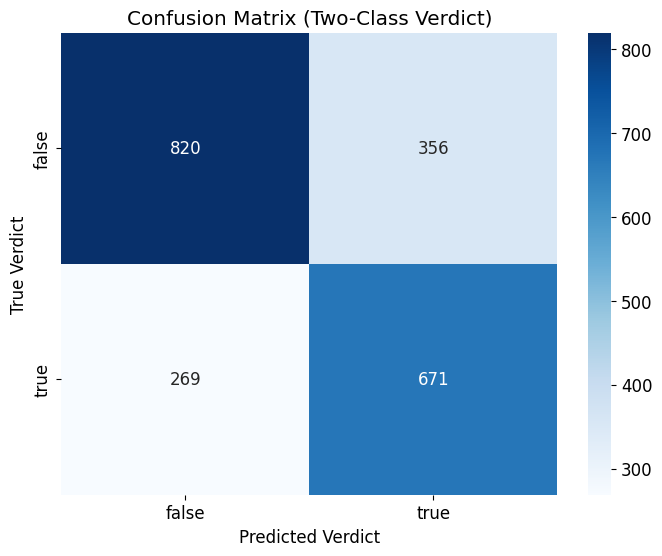


--- 2-Class Logistic Regression Model Metrics ---
Recall (Logistic Regression): 0.697
Precision (Logistic Regression): 0.753
AUC (Logistic Regression): 0.769


In [9]:
# Confusion Matrix for the 2-class problem (using the second two-class mapping)
y_pred_two_class = clf_two_class.predict(X_test_two_class)
two_class_order = ['false', 'true'] # Assuming the two classes are 'false' and 'true' based on the mapping
cm_two_class = confusion_matrix(y_test_two_class, y_pred_two_class, labels=[0,1])

plt.figure(figsize=(8, 6))
sns.heatmap(cm_two_class, annot=True, fmt='d', cmap='Blues', xticklabels=two_class_order, yticklabels=two_class_order)
plt.title('Confusion Matrix (Two-Class Verdict)')
plt.xlabel('Predicted Verdict')
plt.ylabel('True Verdict')
plt.show()


# Evaluate Recall, Precision, and AUC for the 2-class Logistic Regression Model
y_true_lr = y_test_two_class.tolist()

# Get prediction probabilities for AUC
y_pred_proba_lr = clf_two_class.predict_proba(X_test_two_class)

# Calculate metrics
recall_lr = recall_score(y_true_lr, y_pred_two_class, average='binary', zero_division=0, pos_label=0)
precision_lr = precision_score(y_true_lr, y_pred_two_class, average='binary', zero_division=0, pos_label=0)
auc_lr = roc_auc_score(y_true_lr, y_pred_proba_lr[:, 1])

print("\n--- 2-Class Logistic Regression Model Metrics ---")
print(f"Recall (Logistic Regression): {recall_lr:.3f}")
print(f"Precision (Logistic Regression): {precision_lr:.3f}")
print(f"AUC (Logistic Regression): {auc_lr:.3f}")

---
# Deep-Learning Model: AWD-LSTM
For each of the three classification problems we fine-tune the pretrained AWD-LSTM provided by Fast AI. This consists of two steps:
1. Train a language model on the corpus. This model takes in segments of text from the corpus, and aims to predict the next word in the segment of text. Since this is separate from the classification process, we feed in the training and validation sets WITHOUT the oversampled entries in the training set.
2. Using the language model as the body of the LSTM, we replace the head of the model with a classification layer that has an output for each class. Then, we feed in the oversampled training set, and the validation set, to train the LSTM for classification.

In order to boost accuracy of the LSTM model, we construct two additional LSTM models.
* A backward model that reads the texts in backwards order (words are not reversed but the order of words is reversed)
* A combined model that takes the predictions of the forwards and backwards models and constructs a combined prediction.

In [10]:
# Create df of train-validation without oversampled data
# We also use the validation set indices to add a column isValid for the dataloader
X_train_val_six_class_temp = pd.concat([pd.DataFrame(X_train_six_class), pd.DataFrame(X_val_six_class)])[0].values
valid_idx_six_class_temp = range(len(X_train_six_class), len(X_train_val_six_class_temp))
isValid_temp = [True if i in valid_idx_six_class_temp else False for i in range(len(X_train_val_six_class_temp))]
train_val_six_class_df_temp = pd.DataFrame({'text': X_train_val_six_class_temp, 'is_valid': isValid_temp})

# Create df of train-validation with oversampled data
valid_idx_six_class = range(len(X_train_six_class_resampled), len(X_train_val_six_class))
isValid = [True if i in valid_idx_six_class else False for i in range(len(X_train_val_six_class))]
train_val_six_class_df = pd.DataFrame({'text': X_train_val_six_class, 'verdict': y_train_val_six_class.astype(float), 'is_valid': isValid})

---
## Forward Language Model

In [11]:
start = time.time()
# 1) Text block for LM
tb_lm_forward = TextBlock.from_df(
    'text',
    is_lm=True,
    seq_len=80
)

# 2) DataBlock with explicit IndexSplitter
dblock_lm_forward = DataBlock(
    blocks=tb_lm_forward,                      # only X for LM; Y is auto-shifted
    get_x=ColReader('text'),
    splitter=IndexSplitter(valid_idx_six_class_temp)
)

# 3) Build LM DataLoaders
dls_lm_forward = dblock_lm_forward.dataloaders(
    train_val_six_class_df_temp,
    bs=128
)

cbs = [RNNRegularizer(alpha=2., beta=2.)]

learn_forward = language_model_learner(
    dls_lm_forward, AWD_LSTM, drop_mult=0.3,
    metrics=[accuracy, Perplexity()],
    wd=0.1,
    cbs=cbs,
    pretrained=True) #LLM learner

num_epochs = 8
num_frozen = 3
learn_forward.fine_tune(num_epochs, freeze_epochs=num_frozen)
# save the encoder (the model not including the final layer)
# the final layer is task specific: converts activations to probabilities of picking each token in our vocabulary
learn_forward.save_encoder('finetuned_forward')
end = time.time()
print(f'Time to train forward language model: {end-start:.2f} seconds')

epoch,train_loss,valid_loss,accuracy,perplexity,time
0,4.943926,4.761292,0.241415,116.896805,00:11
1,4.688485,4.282163,0.281735,72.396843,00:10
2,4.297505,3.843708,0.302252,46.698322,00:10


epoch,train_loss,valid_loss,accuracy,perplexity,time
0,3.703921,3.609309,0.348142,36.940517,00:11
1,3.614593,3.504839,0.365341,33.276085,00:11
2,3.509278,3.430338,0.371295,30.887085,00:11
3,3.420090,3.379585,0.375921,29.358572,00:11
4,3.348453,3.349085,0.377947,28.476662,00:11
5,3.299048,3.333995,0.380245,28.050182,00:11
6,3.267595,3.328523,0.380808,27.897099,00:11
7,3.263003,3.327467,0.380410,27.867657,00:11


Time to train forward language model: 127.26 seconds


---
## Backward Language Model

In [12]:
# Reverse the order of words in the 'text' column
train_val_six_class_df_temp['text'] = train_val_six_class_df['text'].apply(lambda x: ' '.join(x.split()[::-1]) if isinstance(x, str) else x)

In [13]:
start = time.time()
# 1) Text block for LM
tb_lm_backward = TextBlock.from_df(
    'text',
    is_lm=True,
    seq_len=80
)

# 2) DataBlock with explicit IndexSplitter
dblock_lm_backward = DataBlock(
    blocks=tb_lm_backward,                      # only X for LM; Y is auto-shifted
    get_x=ColReader('text'),
    splitter=IndexSplitter(valid_idx_six_class_temp)
)

# 3) Build LM DataLoaders
dls_lm_backward = dblock_lm_backward.dataloaders(
    train_val_six_class_df_temp,
    bs=128
)

cbs = [RNNRegularizer(alpha=2., beta=1.)]

learn_backward = language_model_learner(
    dls_lm_backward, AWD_LSTM, drop_mult=0.3,
    metrics=[accuracy, Perplexity()],
    wd=0.1,
    cbs=cbs,
    pretrained=True) #LLM learner

num_epochs = 12
num_frozen = 6
learn_backward.fine_tune(num_epochs, freeze_epochs=num_frozen)
# save the encoder (the model not including the final layer)
# the final layer is task specific: converts activations to probabilities of picking each token in our vocabulary
learn_backward.save_encoder('finetuned_backward')
end = time.time()
print(f'Time to train backward language model: {end-start:.2f} seconds')

epoch,train_loss,valid_loss,accuracy,perplexity,time
0,7.618010,7.584330,0.077174,1967.128418,00:11
1,7.431024,7.187259,0.086337,1322.473633,00:10
2,7.035939,6.529695,0.119696,685.189209,00:10
3,6.466481,5.825231,0.165220,338.739410,00:10
4,5.895432,5.350101,0.212037,210.629562,00:10
5,5.467519,5.080135,0.235612,160.795746,00:11


epoch,train_loss,valid_loss,accuracy,perplexity,time
0,4.967433,4.939217,0.254313,139.660858,00:11
1,4.876280,4.782610,0.273387,119.415665,00:11
2,4.740220,4.601883,0.290381,99.671860,00:11
3,4.588009,4.435716,0.308160,84.412552,00:11
4,4.439847,4.299776,0.320123,73.683296,00:11
5,4.326461,4.197307,0.329584,66.506996,00:11
6,4.227335,4.122370,0.337905,61.705326,00:11
7,4.153700,4.069448,0.342462,58.524620,00:11
8,4.100233,4.036057,0.345627,56.602745,00:11
9,4.053583,4.018611,0.347235,55.623814,00:11


Time to train backward language model: 205.03 seconds


---
## 6-Class Classification with AWD-LSTM

Minimum/10: 2.09e-02, steepest point: 7.59e-07


epoch,train_loss,valid_loss,accuracy,time
0,1.665875,1.647179,0.277541,00:05


epoch,train_loss,valid_loss,accuracy,time
0,1.634943,1.628581,0.284634,00:05


epoch,train_loss,valid_loss,accuracy,time
0,1.571180,1.632957,0.278487,00:06


epoch,train_loss,valid_loss,accuracy,time
0,1.473553,1.638443,0.294090,00:06
1,1.400836,1.672927,0.274704,00:06
2,1.328972,1.678550,0.285106,00:06
3,1.276937,1.678332,0.288416,00:06


Time to train forward model: 52.18 seconds


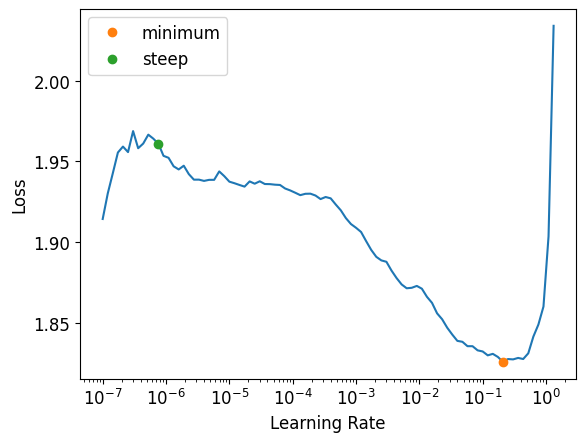

In [14]:
start = time.time()
dls_clas_forward = TextDataLoaders.from_df(
    df=train_val_six_class_df,
    text_col='text',
    label_col='verdict',
    valid_col='is_valid',
    bs=128,
    seq_len=80,
    text_vocab=dls_lm_forward.vocab # reuse LM vocab
)

learn_forward = text_classifier_learner(dls_clas_forward, AWD_LSTM, drop_mult=0.5, metrics=accuracy,
                                cbs = cbs, wd=0.1)

# make sure to add the encoder from the fine-tuned language model!!
learn_forward = learn_forward.load_encoder('finetuned_forward')

learn_forward.freeze_to(-1)
lr_min, lr_steep = learn_forward.lr_find(suggest_funcs=(minimum, steep))
print(f"Minimum/10: {lr_min:.2e}, steepest point: {lr_steep:.2e}");
learn_forward.fit_one_cycle(1, lr_min)

learn_forward.freeze_to(-2)
learn_forward.fit_one_cycle(1, slice(1e-2/(2.6**4),1e-2))

learn_forward.freeze_to(-3)
learn_forward.fit_one_cycle(1, slice(5e-3/(2.6**4),5e-3))

learn_forward.unfreeze()
learn_forward.fit_one_cycle(4, slice(1e-3/(2.6**4),1e-3))
end = time.time()
print(f'Time to train forward model: {end-start:.2f} seconds')

In [15]:
metrics = learn_forward.validate()
print("The validation accuracy for forward model is: ", metrics[1])

#Calculate test df accuracy
texts  = X_test_six_class
test_dl = learn_forward.dls.test_dl(texts)

y_idx = y_test_six_class

preds_forward_prob = learn_forward.get_preds(dl=test_dl)

from sklearn.metrics import accuracy_score

y_hat_forward = preds_forward_prob[0].argmax(dim=1)

acc = accuracy_score(y_idx, y_hat_forward)
print(f"\n The test accuracy for forward model is: {acc:.3f}\n")

The validation accuracy for forward model is:  0.2884160876274109



 The test accuracy for forward model is: 0.292



In [16]:
# Reverse the order of words in the 'text' column
train_val_six_class_df['text'] = train_val_six_class_df['text'].apply(lambda x: ' '.join(x.split()[::-1]) if isinstance(x, str) else x)

Minimum/10: 3.63e-02, steepest point: 1.91e-06


epoch,train_loss,valid_loss,accuracy,time
0,1.677548,1.647462,0.287943,00:05


epoch,train_loss,valid_loss,accuracy,time
0,1.651739,1.633423,0.288889,00:06


epoch,train_loss,valid_loss,accuracy,time
0,1.596296,1.634974,0.298345,00:06


epoch,train_loss,valid_loss,accuracy,time
0,1.528824,1.622606,0.310165,00:06
1,1.486340,1.623705,0.312057,00:06


Time to train backward model: 39.14 seconds


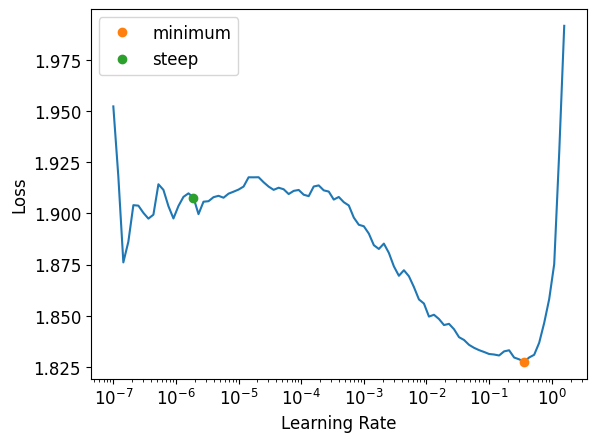

In [17]:
start = time.time()
dls_clas_backward = TextDataLoaders.from_df(
    df=train_val_six_class_df,
    text_col='text',
    label_col='verdict',
    valid_col='is_valid',
    bs=128,
    seq_len=80,
    text_vocab=dls_lm_backward.vocab # reuse LM vocab
)

learn_backward = text_classifier_learner(dls_clas_backward, AWD_LSTM, drop_mult=0.5, metrics=accuracy,
                                cbs = cbs, wd=0.1)

# make sure to add the encoder from the fine-tuned language model!!
learn_backward = learn_backward.load_encoder('finetuned_backward')

learn_backward.freeze_to(-1)
lr_min, lr_steep = learn_backward.lr_find(suggest_funcs=(minimum, steep))
print(f"Minimum/10: {lr_min:.2e}, steepest point: {lr_steep:.2e}");
learn_backward.fit_one_cycle(1, lr_min, wd=0.1)

learn_backward.freeze_to(-2)
learn_backward.fit_one_cycle(1, slice(1e-2/(2.6**4),1e-2))

learn_backward.freeze_to(-3)
learn_backward.fit_one_cycle(1, slice(5e-3/(2.6**4),5e-3))

learn_backward.unfreeze()
learn_backward.fit_one_cycle(2, slice(1e-3/(2.6**4),1e-3))
end = time.time()
print(f'Time to train backward model: {end-start:.2f} seconds')

In [18]:
metrics = learn_backward.validate()
print("The validation accuracy for backward model is: ", metrics[1])

#Calculate test df accuracy
backward_texts  = [ ' '.join(x.split()[::-1]) if isinstance(x, str) else x for x in X_test_six_class ] # Apply word reversal using a list comprehension
backward_test_dl = learn_backward.dls.test_dl(backward_texts)

y_idx = y_test_six_class

preds_backward_prob = learn_backward.get_preds(dl=backward_test_dl)

y_hat_backward = preds_backward_prob[0].argmax(dim=1)

acc = accuracy_score(y_idx, y_hat_backward)
print(f"\n Test accuracy for backward model is: {acc:.3f}\n")

The validation accuracy for backward model is:  0.3120567500591278



 Test accuracy for backward model is: 0.292



In [19]:
preds_forward_prob = learn_forward.get_preds(dl=test_dl)[0]
preds_backward_prob = learn_backward.get_preds(dl=backward_test_dl)[0]
preds_prob = preds_forward_prob + preds_backward_prob

y_hat = preds_prob.argmax(dim=1)

acc = accuracy_score(y_idx, y_hat)
print(f"\n The test accuracy for combined model is: : {acc:.3f}\n")


 The test accuracy for combined model is: : 0.300



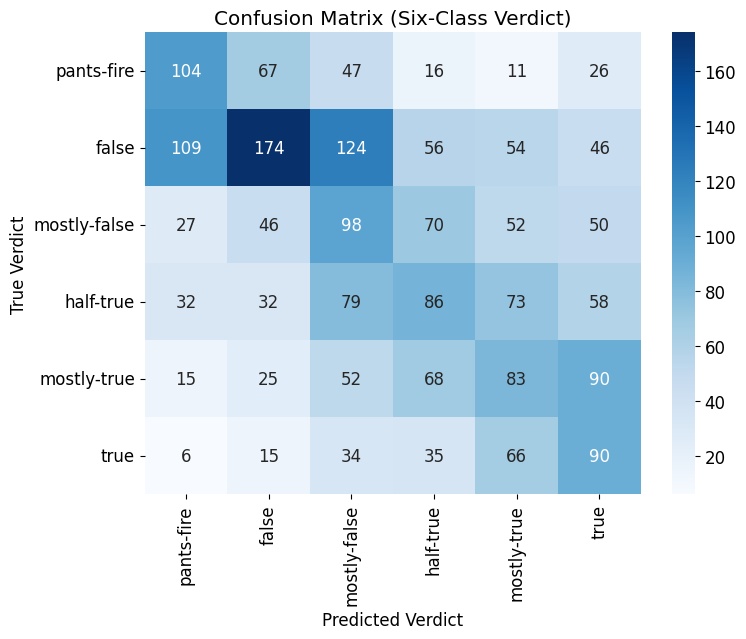

In [20]:
cm_six_class = confusion_matrix(y_test_six_class, y_hat, labels=[0,1,2,3,4,5])

plt.figure(figsize=(8, 6))
sns.heatmap(cm_six_class, annot=True, fmt='d', cmap='Blues', xticklabels=verdict_order, yticklabels=verdict_order)
plt.title('Confusion Matrix (Six-Class Verdict)')
plt.xlabel('Predicted Verdict')
plt.ylabel('True Verdict')
plt.show()

In [21]:
# --- Forward Model Metrics ---
print("\n--- Forward Model Metrics ---")

y_true = y_test_six_class.tolist()

recall_forward = recall_score(y_idx, y_hat_forward, average='macro')
precision_forward = precision_score(y_idx, y_hat_forward, average='macro')
auc_forward = roc_auc_score(y_idx, preds_forward_prob, average='macro', multi_class='ovr')

print(f"Recall (Forward Model): {recall_forward:.3f}")
print(f"Precision (Forward Model): {precision_forward:.3f}")
print(f"AUC (Forward Model): {auc_forward:.3f}")

# --- Backward Model Metrics ---
print("\n--- Backward Model Metrics ---")

recall_backward = recall_score(y_idx, y_hat_backward, average='macro')
precision_backward = precision_score(y_idx, y_hat_backward, average='macro')
auc_backward = roc_auc_score(y_idx, preds_backward_prob, average='macro', multi_class='ovr')

print(f"Recall (Backward Model): {recall_backward:.3f}")
print(f"Precision (Backward Model): {precision_backward:.3f}")
print(f"AUC (Backward Model): {auc_backward:.3f}")

# --- Combined Model Metrics ---
print("\n--- Combined Model Metrics ---")

recall_combined = recall_score(y_idx, y_hat, average='macro')
precision_combined = precision_score(y_idx, y_hat, average='macro')
auc_combined = roc_auc_score(y_idx, preds_prob/2, average='macro', multi_class='ovr')

print(f"Recall (Combined Model): {recall_combined:.3f}")
print(f"Precision (Combined Model): {precision_combined:.3f}")
print(f"AUC (Combined Model): {auc_combined:.3f}")


--- Forward Model Metrics ---
Recall (Forward Model): 0.302
Precision (Forward Model): 0.297
AUC (Forward Model): 0.682

--- Backward Model Metrics ---
Recall (Backward Model): 0.292
Precision (Backward Model): 0.295
AUC (Backward Model): 0.676

--- Combined Model Metrics ---
Recall (Combined Model): 0.305
Precision (Combined Model): 0.303
AUC (Combined Model): 0.692


---
## 3-Class Classification with AWD-LSTM

In [22]:
valid_idx_three_class = range(len(X_train_three_class_resampled), len(X_train_val_three_class))
isValid = [True if i in valid_idx_three_class else False for i in range(len(X_train_val_three_class))]
train_val_three_class_df = pd.DataFrame({'text': X_train_val_three_class, 'verdict': y_train_val_three_class, 'is_valid': isValid})

Minimum/10: 6.92e-03, steepest point: 2.75e-06


epoch,train_loss,valid_loss,accuracy,time
0,0.999910,0.984167,0.499409,00:04


epoch,train_loss,valid_loss,accuracy,time
0,0.990915,0.977612,0.510343,00:05


epoch,train_loss,valid_loss,accuracy,time
0,0.965635,0.964631,0.519208,00:05


epoch,train_loss,valid_loss,accuracy,time
0,0.923404,0.961899,0.516548,00:05
1,0.897273,0.967514,0.517435,00:05
2,0.853551,0.984185,0.505910,00:05
3,0.830643,0.986847,0.514480,00:05


Time to train forward model: 46.92 seconds


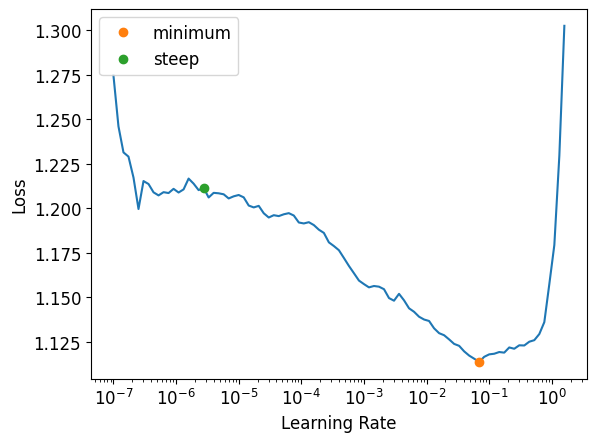

In [23]:
start = time.time()
dls_clas_forward = TextDataLoaders.from_df(
    df=train_val_three_class_df,
    text_col='text',
    label_col='verdict',
    valid_col='is_valid',
    bs=128,
    seq_len=80,
    text_vocab=dls_lm_forward.vocab # reuse LM vocab
)

learn_forward = text_classifier_learner(dls_clas_forward, AWD_LSTM, drop_mult=0.5, metrics=accuracy,
                                cbs = cbs, wd=0.1)

# make sure to add the encoder from the fine-tuned language model!!
learn_forward = learn_forward.load_encoder('finetuned_forward')

learn_forward.freeze_to(-1)
lr_min, lr_steep = learn_forward.lr_find(suggest_funcs=(minimum, steep))
print(f"Minimum/10: {lr_min:.2e}, steepest point: {lr_steep:.2e}");
learn_forward.fit_one_cycle(1, lr_min, wd=0.1)

learn_forward.freeze_to(-2)
learn_forward.fit_one_cycle(1, slice(1e-2/(2.6**4),1e-2))

learn_forward.freeze_to(-3)
learn_forward.fit_one_cycle(1, slice(5e-3/(2.6**4),5e-3))

learn_forward.unfreeze()
learn_forward.fit_one_cycle(4, slice(1e-3/(2.6**4),1e-3))
end = time.time()
print(f'Time to train forward model: {end-start:.2f} seconds')

In [24]:
metrics = learn_forward.validate()
print("The validation accuracy for forward model is: ", metrics[1])

#Calculate test df accuracy
texts  = X_test_three_class
test_dl = learn_forward.dls.test_dl(texts)

y_idx = y_test_three_class

preds_forward_prob = learn_forward.get_preds(dl=test_dl)

y_hat_forward = preds_forward_prob[0].argmax(dim=1)

acc = accuracy_score(y_idx, y_hat_forward)
print(f"\n The test accuracy for forward model is: : {acc:.3f}\n")

The validation accuracy for forward model is:  0.51447993516922



 The test accuracy for forward model is: : 0.518



In [25]:
# Reverse the order of words in the 'text' column
train_val_three_class_df['text'] = train_val_three_class_df['text'].apply(lambda x: ' '.join(x.split()[::-1]) if isinstance(x, str) else x)

Minimum/10: 4.37e-02, steepest point: 1.20e-05


epoch,train_loss,valid_loss,accuracy,time
0,1.016918,0.988183,0.496749,00:04


epoch,train_loss,valid_loss,accuracy,time
0,0.998600,0.986997,0.503842,00:05


epoch,train_loss,valid_loss,accuracy,time
0,0.975202,0.974833,0.513002,00:05


epoch,train_loss,valid_loss,accuracy,time
0,0.954729,0.974290,0.509752,00:05
1,0.931971,0.973745,0.516844,00:05
2,0.907873,0.977318,0.519504,00:05
3,0.893041,0.979855,0.513298,00:06


Time to train backward model: 46.48 seconds


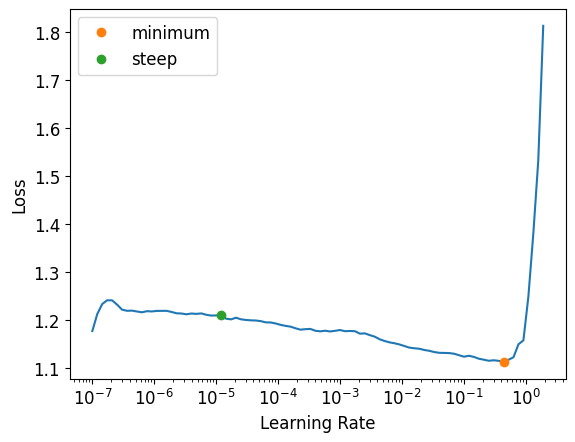

In [26]:
start = time.time()
dls_clas_backward = TextDataLoaders.from_df(
    df=train_val_three_class_df,
    text_col='text',
    label_col='verdict',
    valid_col='is_valid',
    bs=128,
    seq_len=80,
    text_vocab=dls_lm_backward.vocab # reuse LM vocab
)

learn_backward = text_classifier_learner(dls_clas_backward, AWD_LSTM, drop_mult=0.5, metrics=accuracy,
                                cbs = cbs, wd=0.1)

# make sure to add the encoder from the fine-tuned language model!!
learn_backward = learn_backward.load_encoder('finetuned_backward')

learn_backward.freeze_to(-1)
lr_min, lr_steep = learn_backward.lr_find(suggest_funcs=(minimum, steep))
print(f"Minimum/10: {lr_min:.2e}, steepest point: {lr_steep:.2e}");
learn_backward.fit_one_cycle(1, lr_min, wd=0.1)

learn_backward.freeze_to(-2)
learn_backward.fit_one_cycle(1, slice(1e-2/(2.6**4),1e-2))

learn_backward.freeze_to(-3)
learn_backward.fit_one_cycle(1, slice(5e-3/(2.6**4),5e-3))

learn_backward.unfreeze()
learn_backward.fit_one_cycle(4, slice(1e-3/(2.6**4),1e-3))
end = time.time()
print(f'Time to train backward model: {end-start:.2f} seconds')

In [27]:
metrics = learn_backward.validate()
print("The validation accuracy for backward model is: ", metrics[1])

#Calculate test df accuracy
backward_texts  = [ ' '.join(x.split()[::-1]) if isinstance(x, str) else x for x in X_test_three_class ] # Apply word reversal using a list comprehension
backward_test_dl = learn_backward.dls.test_dl(backward_texts)

y_idx = y_test_three_class

preds_backward_prob = learn_backward.get_preds(dl=backward_test_dl)

y_hat_backward = preds_backward_prob[0].argmax(dim=1)

acc = accuracy_score(y_idx, y_hat_backward)
print(f"\n Test accuracy for backward model is: {acc:.3f}\n")

The validation accuracy for backward model is:  0.5132978558540344



 Test accuracy for backward model is: 0.524



In [28]:
preds_forward_prob = learn_forward.get_preds(dl=test_dl)[0]
preds_backward_prob = learn_backward.get_preds(dl=backward_test_dl)[0]
preds_prob = preds_forward_prob + preds_backward_prob

y_hat = preds_prob.argmax(dim=1)

acc = accuracy_score(y_idx, y_hat)
print(f"\n The test accuracy for combined model is: : {acc:.3f}\n")


 The test accuracy for combined model is: : 0.548



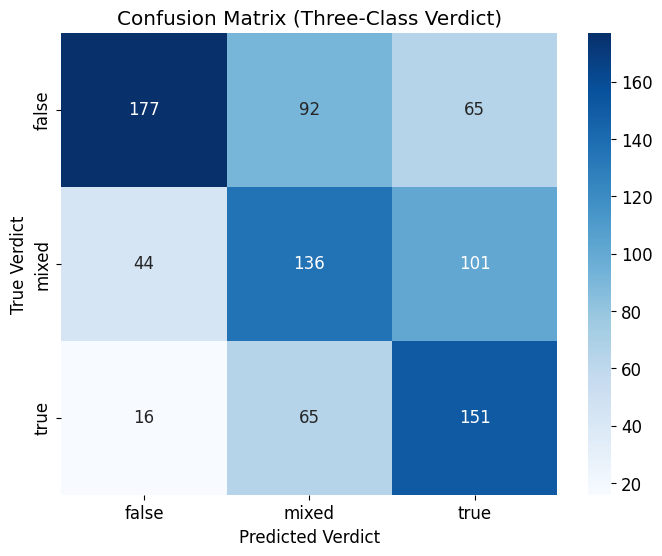

In [29]:
three_class_order = ['false', 'mixed', 'true'] # Assuming the two classes are 'false' and 'true' based on the mapping
cm_three_class = confusion_matrix(y_test_three_class, y_hat, labels=[0,1,2])

plt.figure(figsize=(8, 6))
sns.heatmap(cm_three_class, annot=True, fmt='d', cmap='Blues', xticklabels=three_class_order, yticklabels=three_class_order)
plt.title('Confusion Matrix (Three-Class Verdict)')
plt.xlabel('Predicted Verdict')
plt.ylabel('True Verdict')
plt.show()

In [30]:
# --- Forward Model Metrics ---
print("\n--- Forward Model Metrics ---")

# Convert y_test_two_class to a list for sklearn functions
y_true = y_test_three_class.tolist()

recall_forward = recall_score(y_idx, y_hat_forward, average='macro')
precision_forward = precision_score(y_idx, y_hat_forward, average='macro')
auc_forward = roc_auc_score(y_idx, preds_forward_prob, multi_class='ovr', average='macro')

print(f"Recall (Forward Model): {recall_forward:.3f}")
print(f"Precision (Forward Model): {precision_forward:.3f}")
print(f"AUC (Forward Model): {auc_forward:.3f}")

# --- Backward Model Metrics ---
print("\n--- Backward Model Metrics ---")

recall_backward = recall_score(y_idx, y_hat_backward, average='macro')
precision_backward = precision_score(y_idx, y_hat_backward, average='macro')
auc_backward = roc_auc_score(y_idx, preds_backward_prob, multi_class='ovr', average='macro')

print(f"Recall (Backward Model): {recall_backward:.3f}")
print(f"Precision (Backward Model): {precision_backward:.3f}")
print(f"AUC (Backward Model): {auc_backward:.3f}")

# --- Combined Model Metrics ---
print("\n--- Combined Model Metrics ---")

recall_combined = recall_score(y_idx, y_hat, average='macro')
precision_combined = precision_score(y_idx, y_hat, average='macro')
auc_combined = roc_auc_score(y_idx, preds_prob/2, multi_class='ovr', average='macro')

print(f"Recall (Combined Model): {recall_combined:.3f}")
print(f"Precision (Combined Model): {precision_combined:.3f}")
print(f"AUC (Combined Model): {auc_combined:.3f}")


--- Forward Model Metrics ---
Recall (Forward Model): 0.522
Precision (Forward Model): 0.538
AUC (Forward Model): 0.713

--- Backward Model Metrics ---
Recall (Backward Model): 0.535
Precision (Backward Model): 0.538
AUC (Backward Model): 0.714

--- Combined Model Metrics ---
Recall (Combined Model): 0.555
Precision (Combined Model): 0.562
AUC (Combined Model): 0.724


---
## 2-Class Classification with AWD-LSTM

In [31]:
valid_idx_two_class = range(len(X_train_two_class_resampled), len(X_train_val_two_class))
isValid = [True if i in valid_idx_two_class else False for i in range(len(X_train_val_two_class))]
train_val_two_class_df = pd.DataFrame({'text': X_train_val_two_class, 'verdict': y_train_val_two_class, 'is_valid': isValid})

Minimum/10: 1.74e-02, steepest point: 6.31e-07


epoch,train_loss,valid_loss,accuracy,time
0,0.626921,0.607903,0.645390,00:04


epoch,train_loss,valid_loss,accuracy,time
0,0.611431,0.606572,0.646336,00:04


epoch,train_loss,valid_loss,accuracy,time
0,0.593352,0.600386,0.658629,00:05


epoch,train_loss,valid_loss,accuracy,time
0,0.568373,0.589037,0.678487,00:05
1,0.552096,0.594318,0.677541,00:05
2,0.531265,0.592685,0.687470,00:05
3,0.513730,0.594854,0.683688,00:05


Time to train forward model: 43.84 seconds


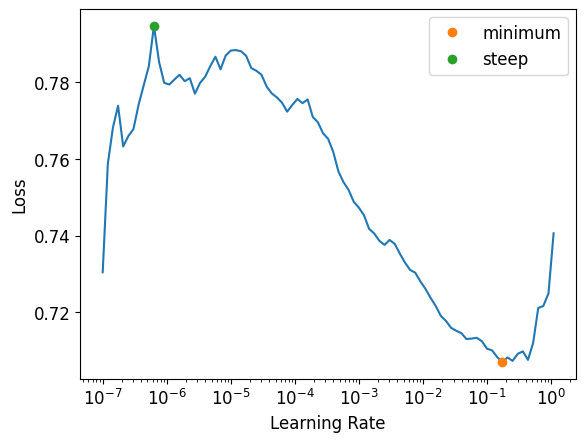

In [32]:
start = time.time()
dls_clas_forward = TextDataLoaders.from_df(
    df=train_val_two_class_df,
    text_col='text',
    label_col='verdict',
    valid_col='is_valid',
    bs=128,
    seq_len=80,
    text_vocab=dls_lm_forward.vocab # reuse LM vocab
)

learn_forward = text_classifier_learner(dls_clas_forward, AWD_LSTM, drop_mult=0.5, metrics=accuracy,
                                cbs = cbs, wd=0.1)

# make sure to add the encoder from the fine-tuned language model!!
learn_forward = learn_forward.load_encoder('finetuned_forward')

learn_forward.freeze_to(-1)
lr_min, lr_steep = learn_forward.lr_find(suggest_funcs=(minimum, steep))
print(f"Minimum/10: {lr_min:.2e}, steepest point: {lr_steep:.2e}");
learn_forward.fit_one_cycle(1, lr_min, wd=0.1)

learn_forward.freeze_to(-2)
learn_forward.fit_one_cycle(1, slice(1e-2/(2.6**4),1e-2))

learn_forward.freeze_to(-3)
learn_forward.fit_one_cycle(1, slice(5e-3/(2.6**4),5e-3))

learn_forward.unfreeze()
learn_forward.fit_one_cycle(4, slice(1e-3/(2.6**4),1e-3))
end = time.time()
print(f'Time to train forward model: {end-start:.2f} seconds')

In [33]:
metrics = learn_forward.validate()
print("The validation accuracy for forward model is: ", metrics[1])

#Calculate test df accuracy
texts  = X_test_two_class
test_dl = learn_forward.dls.test_dl(texts)

y_idx = y_test_two_class

preds_forward = learn_forward.get_preds(dl=test_dl)

y_hat_forward = preds_forward[0].argmax(dim=1)

acc = accuracy_score(y_idx, y_hat_forward)
print(f"\n The test accuracy for forward model is: {acc:.3f}\n")

The validation accuracy for forward model is:  0.6836879253387451



 The test accuracy for forward model is: 0.702



In [34]:
# Reverse the order of words in the 'text' column
train_val_two_class_df['text'] = train_val_two_class_df['text'].apply(lambda x: ' '.join(x.split()[::-1]) if isinstance(x, str) else x)

Minimum/10: 3.02e-02, steepest point: 6.31e-07


epoch,train_loss,valid_loss,accuracy,time
0,0.626694,0.611689,0.643972,00:04


epoch,train_loss,valid_loss,accuracy,time
0,0.620479,0.607623,0.641135,00:05


epoch,train_loss,valid_loss,accuracy,time
0,0.606609,0.602206,0.650118,00:05


epoch,train_loss,valid_loss,accuracy,time
0,0.584475,0.601676,0.644917,00:05
1,0.576807,0.602637,0.653428,00:05
2,0.559718,0.594031,0.666194,00:05
3,0.546829,0.590040,0.673286,00:05


Time to train backward model: 45.24 seconds


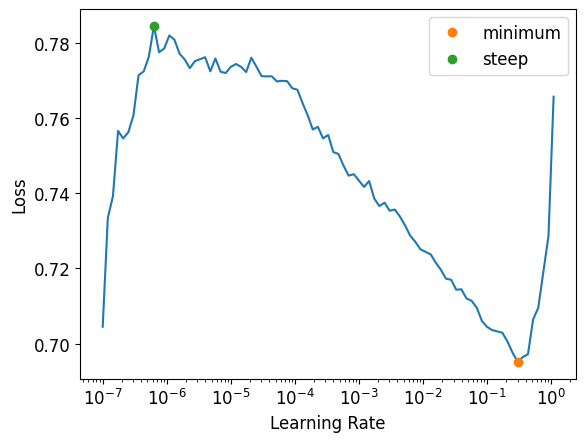

In [35]:
start = time.time()
dls_clas_backward = TextDataLoaders.from_df(
    df=train_val_two_class_df,
    text_col='text',
    label_col='verdict',
    valid_col='is_valid',
    bs=128,
    seq_len=80,
    text_vocab=dls_lm_backward.vocab # reuse LM vocab
)

learn_backward = text_classifier_learner(dls_clas_backward, AWD_LSTM, drop_mult=0.5, metrics=accuracy,
                                cbs = cbs, wd=0.1).to_fp16()

# make sure to add the encoder from the fine-tuned language model!!
learn_backward = learn_backward.load_encoder('finetuned_backward')

learn_backward.freeze_to(-1)
lr_min, lr_steep = learn_backward.lr_find(suggest_funcs=(minimum, steep))
print(f"Minimum/10: {lr_min:.2e}, steepest point: {lr_steep:.2e}");
learn_backward.fit_one_cycle(1, lr_min, wd=0.1)

learn_backward.freeze_to(-2)
learn_backward.fit_one_cycle(1, slice(1e-2/(2.6**4),1e-2))

learn_backward.freeze_to(-3)
learn_backward.fit_one_cycle(1, slice(5e-3/(2.6**4),5e-3))

learn_backward.unfreeze()
learn_backward.fit_one_cycle(4, slice(1e-3/(2.6**4),1e-3))
end = time.time()
print(f'Time to train backward model: {end-start:.2f} seconds')

In [36]:
metrics = learn_backward.validate()
print("The validation accuracy for backward model is: ", metrics[1])

#Calculate test df accuracy
backward_texts  = [ ' '.join(x.split()[::-1]) if isinstance(x, str) else x for x in X_test_two_class ] # Apply word reversal using a list comprehension
backward_test_dl = learn_backward.dls.test_dl(backward_texts)

y_idx = y_test_two_class

preds_backward = learn_backward.get_preds(dl=backward_test_dl)

y_hat_backward = preds_backward[0].argmax(dim=1)

acc = accuracy_score(y_idx, y_hat_backward)
print(f"\n Test accuracy for backward model is: {acc:.3f}\n")

The validation accuracy for backward model is:  0.6732860803604126



 Test accuracy for backward model is: 0.688



In [37]:
preds_forward_prob = learn_forward.get_preds(dl=test_dl)[0]
preds_backward_prob = learn_backward.get_preds(dl=backward_test_dl)[0]
preds_prob = preds_forward_prob + preds_backward_prob

y_hat = preds_prob.argmax(dim=1)

acc = accuracy_score(y_idx, y_hat)
print(f"\n The test accuracy for combined model is: {acc:.3f}\n")


 The test accuracy for combined model is: 0.706



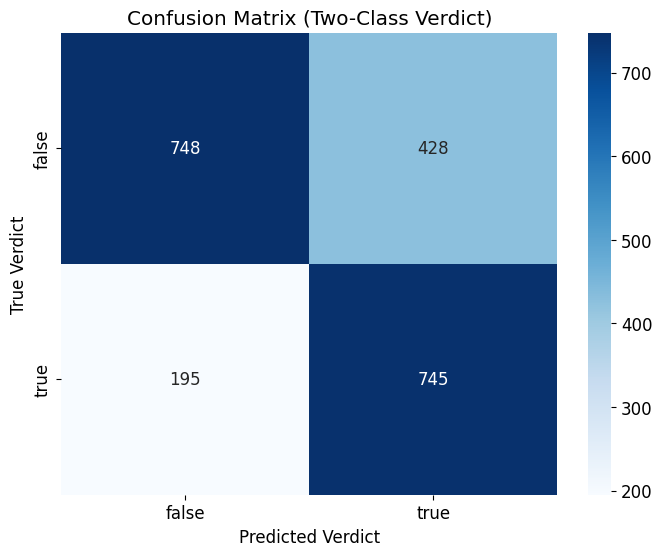

In [38]:
two_class_order = ['false', 'true'] # Assuming the two classes are 'false' and 'true' based on the mapping
cm_two_class = confusion_matrix(y_test_two_class, y_hat, labels=[0,1])

plt.figure(figsize=(8, 6))
sns.heatmap(cm_two_class, annot=True, fmt='d', cmap='Blues', xticklabels=two_class_order, yticklabels=two_class_order)
plt.title('Confusion Matrix (Two-Class Verdict)')
plt.xlabel('Predicted Verdict')
plt.ylabel('True Verdict')
plt.show()

In [39]:
# --- Forward Model Metrics ---
print("\n--- Forward Model Metrics ---")

# Convert y_test_two_class to a list for sklearn functions
y_true = y_test_two_class.tolist()

recall_forward = recall_score(y_idx, y_hat_forward, average='binary', pos_label=0)
precision_forward = precision_score(y_idx, y_hat_forward, average='binary', pos_label=0)
auc_forward = roc_auc_score(y_idx, preds_forward_prob[:,1], labels=[0,1])

print(f"Recall (Forward Model): {recall_forward:.3f}")
print(f"Precision (Forward Model): {precision_forward:.3f}")
print(f"AUC (Forward Model): {auc_forward:.3f}")

# --- Backward Model Metrics ---
print("\n--- Backward Model Metrics ---")

recall_backward = recall_score(y_idx, y_hat_backward, average='binary', pos_label=0)
precision_backward = precision_score(y_idx, y_hat_backward, average='binary', pos_label=0)
auc_backward = roc_auc_score(y_idx, preds_backward_prob[:,1], labels=[0,1])

print(f"Recall (Backward Model): {recall_backward:.3f}")
print(f"Precision (Backward Model): {precision_backward:.3f}")
print(f"AUC (Backward Model): {auc_backward:.3f}")

# --- Combined Model Metrics ---
print("\n--- Combined Model Metrics ---")

recall_combined = recall_score(y_idx, y_hat, average='binary', pos_label=0)
precision_combined = precision_score(y_idx, y_hat, average='binary', pos_label=0)
auc_combined = roc_auc_score(y_idx, preds_prob[:,1]/2, labels=[0,1])

print(f"Recall (Combined Model): {recall_combined:.3f}")
print(f"Precision (Combined Model): {precision_combined:.3f}")
print(f"AUC (Combined Model): {auc_combined:.3f}")


--- Forward Model Metrics ---
Recall (Forward Model): 0.648
Precision (Forward Model): 0.778
AUC (Forward Model): 0.774

--- Backward Model Metrics ---
Recall (Backward Model): 0.612
Precision (Backward Model): 0.779
AUC (Backward Model): 0.765

--- Combined Model Metrics ---
Recall (Combined Model): 0.636
Precision (Combined Model): 0.793
AUC (Combined Model): 0.778
